# MultiPhysio-HRC - Full Preprocessing Notebook

This notebook builds a complete preprocessing pipeline for the MultiPhysio-HRC physiological dataset:

1. Resolve dataset paths
2. Index all subject/task files
3. Clean raw task signals
4. Generate fixed-length windows
5. Build window-level features
6. Normalize features
7. Prepare LOSO-ready artifacts
8. Export reproducible outputs

In [3]:
# SECTION 1: Imports and Global Configuration

import json
import os
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✓ Imports loaded')

✓ Imports loaded


In [4]:
# SECTION 2: Path Resolution and Runtime Settings

@dataclass
class PreprocessingConfig:
    sample_rate_hz: int = 256
    window_seconds: int = 60
    overlap_ratio: float = 0.5
    target_split: str = 'filtered'  # 'filtered' recommended for baseline pipelines
    min_window_coverage: float = 0.95
    normalization_mode: str = 'subject_minmax'  # subject_minmax | global_zscore | none
    max_subjects: int = 0  # 0 => all


CONFIG = PreprocessingConfig()

# Detect environment
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    mounted = False
    try:
        drive.mount('/content/drive', force_remount=False)
        mounted = True
    except Exception as e:
        print(f'⚠️ Drive mount failed, using local /content paths instead: {e}')

    if mounted:
        DATA_DIR = Path('/content/drive/MyDrive/MultiPhysio-HRC')
        OUTPUT_DIR = Path('/content/drive/MyDrive/research_outputs/preprocessing')
    else:
        DATA_DIR = Path('/content/MultiPhysio-HRC')
        OUTPUT_DIR = Path('/content/research_outputs/preprocessing')
else:
    DATA_DIR = Path.home() / 'Desktop' / 'thesis' / 'data' / 'multiphysio_hrc'
    OUTPUT_DIR = Path.home() / 'Desktop' / 'thesis' / 'phd_project' / 'sensor_fusion' / 'outputs' / 'preprocessing'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('✓ Runtime configured')
print(f'  IN_COLAB: {IN_COLAB}')
print(f'  DATA_DIR: {DATA_DIR}')
print(f'  OUTPUT_DIR: {OUTPUT_DIR}')
print('  CONFIG:', asdict(CONFIG))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Runtime configured
  IN_COLAB: True
  DATA_DIR: /content/drive/MyDrive/MultiPhysio-HRC
  OUTPUT_DIR: /content/drive/MyDrive/research_outputs/preprocessing
  CONFIG: {'sample_rate_hz': 256, 'window_seconds': 60, 'overlap_ratio': 0.5, 'target_split': 'filtered', 'min_window_coverage': 0.95, 'normalization_mode': 'subject_minmax', 'max_subjects': 0}


In [6]:
# SECTION 3: Dataset Discovery Utilities

def resolve_dataset_root(base_dir: Path) -> Path:
    base_dir = Path(base_dir)

    if (base_dir / 'physiological_data').exists() or (base_dir / 'features').exists():
        return base_dir

    for child in base_dir.iterdir() if base_dir.exists() else []:
        if child.is_dir() and ((child / 'physiological_data').exists() or (child / 'features').exists()):
            return child

    return base_dir


def discover_subject_task_files(dataset_root: Path, split: str = 'filtered') -> pd.DataFrame:
    physio_root = dataset_root / 'physiological_data' / split
    if not physio_root.exists():
        return pd.DataFrame(columns=['subject_id', 'task_file', 'task_name', 'split', 'file_path'])

    rows = []
    for subj_dir in sorted([d for d in physio_root.iterdir() if d.is_dir()]):
        for csv_file in sorted(subj_dir.glob('*.csv')):
            rows.append({
                'subject_id': subj_dir.name,
                'task_file': csv_file.name,
                'task_name': csv_file.stem,
                'split': split,
                'file_path': str(csv_file),
            })

    return pd.DataFrame(rows)


DATASET_ROOT = resolve_dataset_root(DATA_DIR)
PHYSIO_ROOT = DATASET_ROOT / 'physiological_data'
FEATURES_ROOT = DATASET_ROOT / 'features'

index_df = discover_subject_task_files(DATASET_ROOT, split=CONFIG.target_split)

if CONFIG.max_subjects and CONFIG.max_subjects > 0:
    keep_subjects = sorted(index_df['subject_id'].unique())[:CONFIG.max_subjects]
    index_df = index_df[index_df['subject_id'].isin(keep_subjects)].reset_index(drop=True)

print('✓ Dataset discovered')
print(f'  DATASET_ROOT: {DATASET_ROOT}')
print(f'  PHYSIO_ROOT exists: {PHYSIO_ROOT.exists()}')
print(f'  FEATURES_ROOT exists: {FEATURES_ROOT.exists()}')
print(f'  Indexed rows: {len(index_df)}')
print(f'  Subjects: {index_df.subject_id.nunique() if not index_df.empty else 0}')
print(f'  Tasks: {index_df.task_name.nunique() if not index_df.empty else 0}')

index_df.head(10)

✓ Dataset discovered
  DATASET_ROOT: /content/drive/MyDrive/MultiPhysio-HRC
  PHYSIO_ROOT exists: True
  FEATURES_ROOT exists: False
  Indexed rows: 919
  Subjects: 52
  Tasks: 21


,subject_id,task_file,task_name,split,file_path
0,10000,cobot-task-1.csv,cobot-task-1,filtered,/content/drive/MyDrive/MultiPhysio-HRC/physiol...
1,10000,cobot-task-2.csv,cobot-task-2,filtered,/content/drive/MyDrive/MultiPhysio-HRC/physiol...
2,10000,cobot-task-3.csv,cobot-task-3,filtered,/content/drive/MyDrive/MultiPhysio-HRC/physiol...
3,10000,cobot-task-4.csv,cobot-task-4,filtered,/content/drive/MyDrive/MultiPhysio-HRC/physiol...
4,10000,cobot-task-5.csv,cobot-task-5,filtered,/content/drive/MyDrive/MultiPhysio-HRC/physiol...
5,10000,hanoi_0.csv,hanoi_0,filtered,/content/drive/MyDrive/MultiPhysio-HRC/physiol...
6,10000,manual-task-1.csv,manual-task-1,filtered,/content/drive/MyDrive/MultiPhysio-HRC/physiol...
7,10000,manual-task-2.csv,manual-task-2,filtered,/content/drive/MyDrive/MultiPhysio-HRC/physiol...
8,10000,manual-task-3.csv,manual-task-3,filtered,/content/drive/MyDrive/MultiPhysio-HRC/physiol...
9,10000,manual-task-4.csv,manual-task-4,filtered,/content/drive/MyDrive/MultiPhysio-HRC/physiol...


Subjects with most files:
subject_id
10000    21
10001    21
1001     21
1005     21
1034     21
1007     21
1008     21
1032     21
1037     21
1035     21

Most common tasks:
task_name
stroopeasy_0     51
n-back_0         51
rest_0           51
stroophard_0     51
hanoi_0          51
mat_0            50
meditation_0     50
vr-plank_0       49
manual-task-2    42
rest-2           42
rest-1           42
manual-task-3    42
manual-task-4    42
cobot-task-1     41
manual-task-1    41
manual-task-5    41
cobot-task-2     40
cobot-task-3     39
cobot-task-4     38
cobot-task-5     33


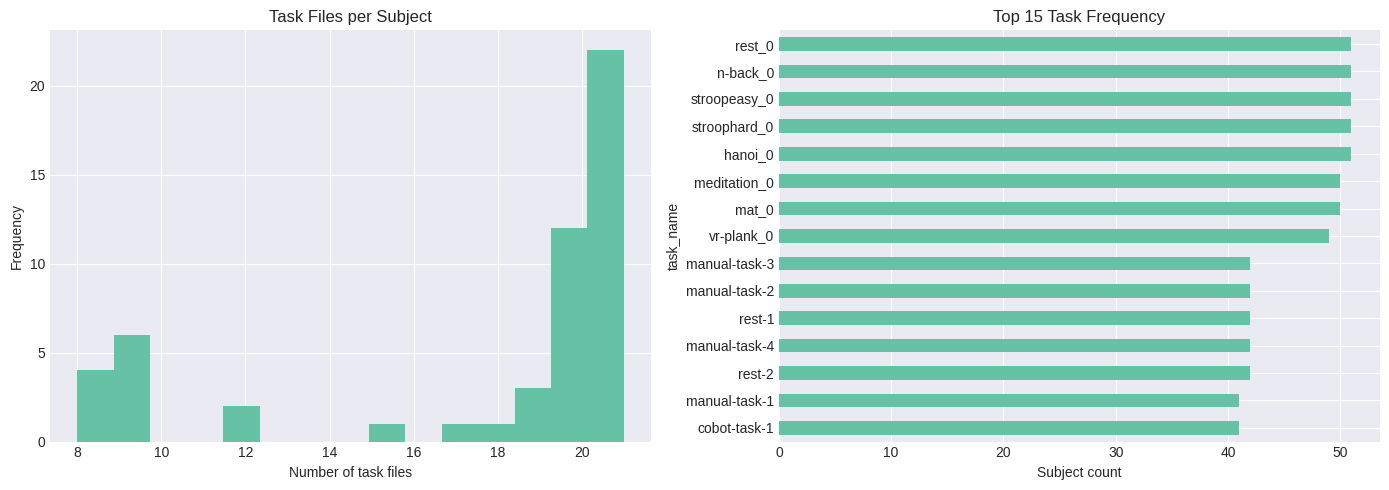

In [7]:
# SECTION 4: Quick Structural Audit

if index_df.empty:
    print('⚠️ No task files found. Check DATA_DIR path and extraction state.')
else:
    per_subject = index_df.groupby('subject_id').size().sort_values(ascending=False)
    per_task = index_df.groupby('task_name').size().sort_values(ascending=False)

    print('Subjects with most files:')
    print(per_subject.head(10).to_string())
    print('\nMost common tasks:')
    print(per_task.head(20).to_string())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    per_subject.plot(kind='hist', bins=15, ax=axes[0], title='Task Files per Subject')
    axes[0].set_xlabel('Number of task files')

    per_task.head(15).sort_values().plot(kind='barh', ax=axes[1], title='Top 15 Task Frequency')
    axes[1].set_xlabel('Subject count')
    plt.tight_layout()
    plt.show()

In [8]:
# SECTION 5: Signal Cleaning Functions

METADATA_CANDIDATES = {'Unnamed: 0', 'ID', 'Repetition', 'id', 'repetition'}


def clean_task_dataframe(df: pd.DataFrame) -> Tuple[pd.DataFrame, Dict]:
    """Clean a task-level signal dataframe and return cleaned frame + report."""
    report = {
        'n_rows_before': len(df),
        'n_cols_before': len(df.columns),
        'dropped_columns': [],
        'n_rows_after': None,
        'n_cols_after': None,
        'n_missing_after': None,
    }

    work = df.copy()

    # Drop obvious metadata/index columns (keep ID/Repetition separately if needed)
    drop_cols = [c for c in work.columns if c in METADATA_CANDIDATES and c.startswith('Unnamed')]
    if drop_cols:
        work = work.drop(columns=drop_cols)
        report['dropped_columns'].extend(drop_cols)

    # Convert numeric-like columns
    for col in work.columns:
        work[col] = pd.to_numeric(work[col], errors='ignore')

    # Keep numeric columns + optional metadata id/repetition
    numeric_cols = work.select_dtypes(include=[np.number]).columns.tolist()
    work = work[numeric_cols].copy()

    # Drop rows that are fully NaN
    work = work.dropna(how='all').reset_index(drop=True)

    # Interpolate + ffill/bfill for sparse NaNs in numeric channels
    if not work.empty:
        work = work.interpolate(limit_direction='both', axis=0)
        work = work.fillna(method='ffill').fillna(method='bfill')

    report['n_rows_after'] = len(work)
    report['n_cols_after'] = len(work.columns)
    report['n_missing_after'] = int(work.isna().sum().sum()) if not work.empty else 0

    return work, report

In [9]:
# SECTION 6: Windowing + Feature Engineering


def sliding_windows(n_samples: int, sample_rate: int, window_seconds: int, overlap_ratio: float) -> List[Tuple[int, int]]:
    window_size = int(sample_rate * window_seconds)
    hop = max(1, int(window_size * (1 - overlap_ratio)))

    windows = []
    start = 0
    while start + window_size <= n_samples:
        windows.append((start, start + window_size))
        start += hop

    return windows


def compute_window_features(window_df: pd.DataFrame, prefix='') -> Dict:
    """Compute compact statistical features for a single window."""
    feats = {}
    for col in window_df.columns:
        s = window_df[col].astype(float)
        base = f'{prefix}{col}'
        feats[f'{base}__mean'] = float(s.mean())
        feats[f'{base}__std'] = float(s.std(ddof=0))
        feats[f'{base}__min'] = float(s.min())
        feats[f'{base}__max'] = float(s.max())
        feats[f'{base}__median'] = float(s.median())
        feats[f'{base}__p25'] = float(s.quantile(0.25))
        feats[f'{base}__p75'] = float(s.quantile(0.75))
        feats[f'{base}__energy'] = float((s ** 2).mean())
    return feats


def preprocess_one_task(file_path: Path, cfg: PreprocessingConfig) -> Tuple[pd.DataFrame, Dict]:
    raw = pd.read_csv(file_path)
    cleaned, clean_report = clean_task_dataframe(raw)

    if cleaned.empty:
        return pd.DataFrame(), {
            'file_path': str(file_path),
            'status': 'empty_after_cleaning',
            'clean_report': clean_report,
            'n_windows': 0,
        }

    windows = sliding_windows(
        n_samples=len(cleaned),
        sample_rate=cfg.sample_rate_hz,
        window_seconds=cfg.window_seconds,
        overlap_ratio=cfg.overlap_ratio,
    )

    rows = []
    for idx, (start, end) in enumerate(windows):
        segment = cleaned.iloc[start:end]
        if len(segment) < int(cfg.sample_rate_hz * cfg.window_seconds * cfg.min_window_coverage):
            continue

        feats = compute_window_features(segment)
        feats['window_idx'] = idx
        feats['start_idx'] = start
        feats['end_idx'] = end
        feats['n_samples'] = len(segment)
        rows.append(feats)

    features_df = pd.DataFrame(rows)

    report = {
        'file_path': str(file_path),
        'status': 'ok',
        'clean_report': clean_report,
        'n_windows': len(features_df),
    }
    return features_df, report

In [10]:
# SECTION 7: Full Preprocessing Run Across Dataset

all_feature_rows = []
all_reports = []

if index_df.empty:
    print('⚠️ No files to preprocess.')
else:
    print(f'Processing {len(index_df)} task files...')

    for rec in tqdm(index_df.to_dict('records')):
        subject_id = rec['subject_id']
        task_name = rec['task_name']
        file_path = Path(rec['file_path'])

        try:
            task_features, report = preprocess_one_task(file_path, CONFIG)

            if not task_features.empty:
                task_features.insert(0, 'subject_id', subject_id)
                task_features.insert(1, 'task_name', task_name)
                task_features.insert(2, 'task_file', file_path.name)
                task_features.insert(3, 'split', rec['split'])
                all_feature_rows.append(task_features)

            report.update({'subject_id': subject_id, 'task_name': task_name, 'task_file': file_path.name})
            all_reports.append(report)

        except Exception as e:
            all_reports.append({
                'subject_id': subject_id,
                'task_name': task_name,
                'task_file': file_path.name,
                'file_path': str(file_path),
                'status': f'error: {e}',
                'n_windows': 0,
            })

preprocessed_df = pd.concat(all_feature_rows, ignore_index=True) if all_feature_rows else pd.DataFrame()
reports_df = pd.DataFrame(all_reports)

print('✓ Preprocessing completed')
print(f'  Window-level rows: {len(preprocessed_df)}')
print(f'  Reports rows: {len(reports_df)}')

if not reports_df.empty:
    print('\nStatus counts:')
    print(reports_df['status'].value_counts(dropna=False).to_string())

if not preprocessed_df.empty:
    print('\nPreprocessed dataframe preview:')
    display(preprocessed_df.head(5))

Processing 919 task files...


  0%|          | 0/919 [00:00<?, ?it/s]

/tmp/ipykernel_14919/2574756366.py:27: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  work[col] = pd.to_numeric(work[col], errors='ignore')
/tmp/ipykernel_14919/2574756366.py:39: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  work = work.fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_14919/2574756366.py:27: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  work[col] = pd.to_numeric(work[col], errors='ignore')
/tmp/ipykernel_14919/2574756366.py:39: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  work = work.fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_149

✓ Preprocessing completed
  Window-level rows: 5640
  Reports rows: 919

Status counts:
status
ok    919

Preprocessed dataframe preview:


,subject_id,task_name,task_file,split,ID__mean,ID__std,ID__min,ID__max,ID__median,ID__p25,ID__p75,ID__energy,Repetition__mean,Repetition__std,Repetition__min,Repetition__max,Repetition__median,Repetition__p25,Repetition__p75,Repetition__energy,ECG__mean,ECG__std,ECG__min,ECG__max,ECG__median,ECG__p25,ECG__p75,ECG__energy,EDA__mean,EDA__std,EDA__min,EDA__max,EDA__median,EDA__p25,EDA__p75,EDA__energy,EMG__mean,EMG__std,EMG__min,EMG__max,EMG__median,EMG__p25,EMG__p75,EMG__energy,RESP__mean,RESP__std,RESP__min,RESP__max,RESP__median,RESP__p25,RESP__p75,RESP__energy,EEG_channel_0__mean,EEG_channel_0__std,EEG_channel_0__min,EEG_channel_0__max,EEG_channel_0__median,EEG_channel_0__p25,EEG_channel_0__p75,EEG_channel_0__energy,EEG_channel_1__mean,EEG_channel_1__std,EEG_channel_1__min,EEG_channel_1__max,EEG_channel_1__median,EEG_channel_1__p25,EEG_channel_1__p75,EEG_channel_1__energy,EEG_channel_2__mean,EEG_channel_2__std,EEG_channel_2__min,EEG_channel_2__max,EEG_channel_2__median,EEG_channel_2__p25,EEG_channel_2__p75,EEG_channel_2__energy,EEG_channel_3__mean,EEG_channel_3__std,EEG_channel_3__min,EEG_channel_3__max,EEG_channel_3__median,EEG_channel_3__p25,EEG_channel_3__p75,EEG_channel_3__energy,EEG_channel_4__mean,EEG_channel_4__std,EEG_channel_4__min,EEG_channel_4__max,EEG_channel_4__median,EEG_channel_4__p25,EEG_channel_4__p75,EEG_channel_4__energy,EEG_channel_5__mean,EEG_channel_5__std,EEG_channel_5__min,EEG_channel_5__max,EEG_channel_5__median,EEG_channel_5__p25,EEG_channel_5__p75,EEG_channel_5__energy,EEG_channel_6__mean,EEG_channel_6__std,EEG_channel_6__min,EEG_channel_6__max,EEG_channel_6__median,EEG_channel_6__p25,EEG_channel_6__p75,EEG_channel_6__energy,EEG_channel_7__mean,EEG_channel_7__std,EEG_channel_7__min,EEG_channel_7__max,EEG_channel_7__median,EEG_channel_7__p25,EEG_channel_7__p75,EEG_channel_7__energy,EEG_channel_8__mean,EEG_channel_8__std,EEG_channel_8__min,EEG_channel_8__max,EEG_channel_8__median,EEG_channel_8__p25,EEG_channel_8__p75,EEG_channel_8__energy,EEG_channel_9__mean,EEG_channel_9__std,EEG_channel_9__min,EEG_channel_9__max,EEG_channel_9__median,EEG_channel_9__p25,EEG_channel_9__p75,EEG_channel_9__energy,EEG_channel_10__mean,EEG_channel_10__std,EEG_channel_10__min,EEG_channel_10__max,EEG_channel_10__median,EEG_channel_10__p25,EEG_channel_10__p75,EEG_channel_10__energy,EEG_channel_11__mean,EEG_channel_11__std,EEG_channel_11__min,EEG_channel_11__max,EEG_channel_11__median,EEG_channel_11__p25,EEG_channel_11__p75,EEG_channel_11__energy,window_idx,start_idx,end_idx,n_samples
0,10000,cobot-task-1,cobot-task-1.csv,filtered,10000.0,0.0,10000.0,10000.0,10000.0,10000.0,10000.0,100000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-2.055193,133.194863,-4770.476750,1375.962603,-36.531920,-54.997281,4.194841,17745.095242,-0.154082,2.643921e-09,-0.154082,-0.154082,-0.154082,-0.154082,-0.154082,0.023741,0.003423,48.846273,-541.070499,352.677630,2.950480,-15.214837,20.622644,2385.958432,25.258725,92.234473,-110.274212,936.540182,-0.937387,-17.053190,22.173971,9145.201128,-0.015526,67.412243,-467.111470,602.253346,0.028433,-23.969184,21.982261,4544.410706,0.145382,81.181883,-1199.598629,284.966415,1.320519,-18.403735,25.000510,6590.519324,0.161007,64.025554,-314.983793,749.247737,-0.729603,-19.819731,15.660447,4099.297444,0.155069,43.521923,-215.677818,307.014830,-0.666074,-18.070047,13.727933,1.894182e+03,0.272720,61.068213,-620.461590,593.286696,-0.136734,-12.115832,12.597639,3729.401009,0.197010,109.342014,-851.355054,1755.030268,-0.028719,-13.514502,12.969917,11955.714808,0.311493,25.031008,-238.947518,311.495915,0.385674,-9.913801,11.560290,626.648400,0.400708,385.132928,-2830.658629,5956.329714,-1.036649,-15.464617,14.511583,148327.532712,0.185579,41.582449,-312.835237,503.754984,-0.601015,-12.911844,10.477554,1729.134509,0.192040,83.696850,-1419.989697,387.735251,0.538593,-13.663040,15.201529,7005.199512,0.190787,25.986274,-169.173514,163.995906,0.326068,-10.173603,10.442892,675.322813,0.266699,49.520802,-453.141202,481.878761,-0.

In [11]:
# SECTION 8: Normalization (Feature Matrix)


def minmax_fit_transform(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series, pd.Series]:
    mins = df.min(axis=0)
    maxs = df.max(axis=0)
    denom = (maxs - mins).replace(0, 1.0)
    out = (df - mins) / denom
    return out, mins, maxs


def zscore_fit_transform(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series, pd.Series]:
    means = df.mean(axis=0)
    stds = df.std(axis=0).replace(0, 1.0)
    out = (df - means) / stds
    return out, means, stds


normalized_df = preprocessed_df.copy()
normalization_artifacts = {}

if not preprocessed_df.empty:
    metadata_cols = ['subject_id', 'task_name', 'task_file', 'split', 'window_idx', 'start_idx', 'end_idx', 'n_samples']
    feature_cols = [c for c in preprocessed_df.columns if c not in metadata_cols]

    if CONFIG.normalization_mode == 'subject_minmax':
        chunks = []
        per_subject_params = {}

        for sid, chunk in preprocessed_df.groupby('subject_id'):
            X = chunk[feature_cols].astype(float)
            Xn, mins, maxs = minmax_fit_transform(X)
            out = chunk.copy()
            out[feature_cols] = Xn
            chunks.append(out)
            per_subject_params[sid] = {
                'mins': mins.to_dict(),
                'maxs': maxs.to_dict(),
            }

        normalized_df = pd.concat(chunks, ignore_index=True)
        normalization_artifacts = {'mode': CONFIG.normalization_mode, 'per_subject': per_subject_params}

    elif CONFIG.normalization_mode == 'global_zscore':
        X = preprocessed_df[feature_cols].astype(float)
        Xn, means, stds = zscore_fit_transform(X)
        normalized_df[feature_cols] = Xn
        normalization_artifacts = {
            'mode': CONFIG.normalization_mode,
            'means': means.to_dict(),
            'stds': stds.to_dict(),
        }

    else:
        normalization_artifacts = {'mode': 'none'}

print('✓ Normalization complete')
print(f"  Mode: {normalization_artifacts.get('mode', 'none')}")
print(f'  Rows: {len(normalized_df)}')
print(f'  Columns: {len(normalized_df.columns)}')

✓ Normalization complete
  Mode: subject_minmax
  Rows: 5640
  Columns: 152


In [12]:
# SECTION 9: LOSO Split Plan + Metadata Manifests


def build_loso_splits(df: pd.DataFrame, subject_col: str = 'subject_id') -> pd.DataFrame:
    subjects = sorted(df[subject_col].unique())
    rows = []
    for sid in subjects:
        test_mask = df[subject_col] == sid
        rows.append({
            'fold_subject': sid,
            'n_train': int((~test_mask).sum()),
            'n_test': int(test_mask.sum()),
        })
    return pd.DataFrame(rows)


loso_df = build_loso_splits(normalized_df) if not normalized_df.empty else pd.DataFrame()

print('✓ LOSO split plan ready')
if not loso_df.empty:
    display(loso_df.head(10))
    print(f'Total folds: {len(loso_df)}')
    print(f'Test size range: {loso_df.n_test.min()} - {loso_df.n_test.max()}')

✓ LOSO split plan ready


,fold_subject,n_train,n_test
0,10000,5477,163
1,10001,5488,152
2,1001,5523,117
3,1002,5593,47
4,1005,5485,155
5,1006,5612,28
6,1007,5505,135
7,1008,5487,153
8,1009,5603,37
9,1013,5622,18


Total folds: 52
Test size range: 18 - 163


In [13]:
# SECTION 10: Save Preprocessed Outputs

export_dir = OUTPUT_DIR / 'v1_windowed'
export_dir.mkdir(parents=True, exist_ok=True)

files_written = []

if not index_df.empty:
    index_path = export_dir / 'task_index.csv'
    index_df.to_csv(index_path, index=False)
    files_written.append(str(index_path))

if not reports_df.empty:
    reports_path = export_dir / 'preprocessing_reports.csv'
    reports_df.to_csv(reports_path, index=False)
    files_written.append(str(reports_path))

if not preprocessed_df.empty:
    raw_features_path = export_dir / 'window_features_raw.csv'
    preprocessed_df.to_csv(raw_features_path, index=False)
    files_written.append(str(raw_features_path))

if not normalized_df.empty:
    norm_features_path = export_dir / 'window_features_normalized.csv'
    normalized_df.to_csv(norm_features_path, index=False)
    files_written.append(str(norm_features_path))

if not loso_df.empty:
    loso_path = export_dir / 'loso_plan.csv'
    loso_df.to_csv(loso_path, index=False)
    files_written.append(str(loso_path))

manifest = {
    'config': asdict(CONFIG),
    'dataset_root': str(DATASET_ROOT),
    'n_task_files_indexed': int(len(index_df)),
    'n_subjects': int(index_df.subject_id.nunique()) if not index_df.empty else 0,
    'n_window_rows_raw': int(len(preprocessed_df)) if 'preprocessed_df' in globals() else 0,
    'n_window_rows_normalized': int(len(normalized_df)) if 'normalized_df' in globals() else 0,
    'normalization_mode': normalization_artifacts.get('mode', 'none') if 'normalization_artifacts' in globals() else 'none',
    'export_files': files_written,
}

manifest_path = export_dir / 'manifest.json'
with open(manifest_path, 'w') as f:
    json.dump(manifest, f, indent=2)
files_written.append(str(manifest_path))

print('✓ Export complete')
for fp in files_written:
    print('  -', fp)

print('\nManifest:')
print(json.dumps(manifest, indent=2))

✓ Export complete
  - /content/drive/MyDrive/research_outputs/preprocessing/v1_windowed/task_index.csv
  - /content/drive/MyDrive/research_outputs/preprocessing/v1_windowed/preprocessing_reports.csv
  - /content/drive/MyDrive/research_outputs/preprocessing/v1_windowed/window_features_raw.csv
  - /content/drive/MyDrive/research_outputs/preprocessing/v1_windowed/window_features_normalized.csv
  - /content/drive/MyDrive/research_outputs/preprocessing/v1_windowed/loso_plan.csv
  - /content/drive/MyDrive/research_outputs/preprocessing/v1_windowed/manifest.json

Manifest:
{
  "config": {
    "sample_rate_hz": 256,
    "window_seconds": 60,
    "overlap_ratio": 0.5,
    "target_split": "filtered",
    "min_window_coverage": 0.95,
    "normalization_mode": "subject_minmax",
    "max_subjects": 0
  },
  "dataset_root": "/content/drive/MyDrive/MultiPhysio-HRC",
  "n_task_files_indexed": 919,
  "n_subjects": 52,
  "n_window_rows_raw": 5640,
  "n_window_rows_normalized": 5640,
  "normalization_mod

/tmp/ipykernel_14919/4255295586.py:16: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(normalized_df[cf], ax=axes[1], label=cf, fill=False)


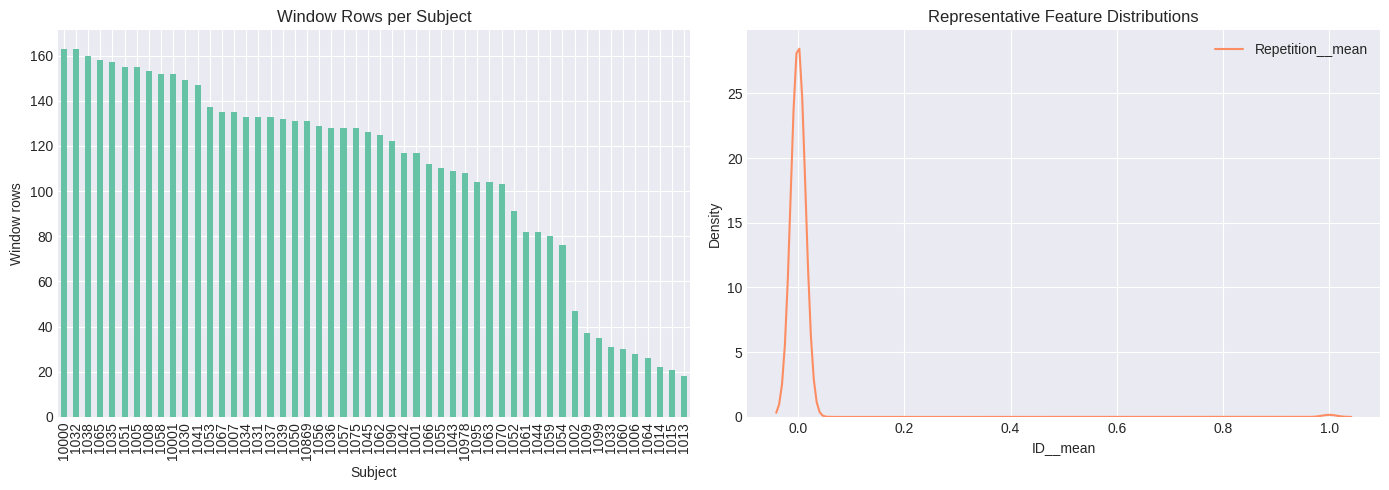

In [14]:
# SECTION 11: Sanity Visualizations of Preprocessed Data

if not normalized_df.empty:
    rows_per_subject = normalized_df.groupby('subject_id').size().sort_values(ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    rows_per_subject.plot(kind='bar', ax=axes[0], title='Window Rows per Subject')
    axes[0].set_xlabel('Subject')
    axes[0].set_ylabel('Window rows')
    axes[0].tick_params(axis='x', rotation=90)

    # Visualize 1-2 representative features if available
    candidate_features = [c for c in normalized_df.columns if c.endswith('__mean')][:2]
    if candidate_features:
        for cf in candidate_features:
            sns.kdeplot(normalized_df[cf], ax=axes[1], label=cf, fill=False)
        axes[1].set_title('Representative Feature Distributions')
        axes[1].legend()
    else:
        axes[1].text(0.5, 0.5, 'No candidate __mean features found', ha='center', va='center')
        axes[1].set_title('Feature Distribution')

    plt.tight_layout()
    plt.show()
else:
    print('⚠️ normalized_df is empty; no visualization generated.')

## Next Steps

1. If labels are available, merge questionnaire labels to each window row using task/subject alignment.
2. Train baseline models with `window_features_normalized.csv` and `loso_plan.csv`.
3. Optionally add signal-level preprocessing variants:
   - Raw vs filtered comparison
   - Different window lengths (10s/30s/60s)
   - Overlap sensitivity analysis
4. Move to multimodal fusion by adding EEG/voice/AU tables when available.

In [15]:
# SECTION 12: Compact Run Summary

compact = {
    'dataset_root': str(DATASET_ROOT) if 'DATASET_ROOT' in globals() else None,
    'indexed_task_files': int(len(index_df)) if 'index_df' in globals() else 0,
    'subjects_indexed': int(index_df.subject_id.nunique()) if 'index_df' in globals() and not index_df.empty else 0,
    'window_rows_raw': int(len(preprocessed_df)) if 'preprocessed_df' in globals() else 0,
    'window_rows_normalized': int(len(normalized_df)) if 'normalized_df' in globals() else 0,
    'loso_folds': int(len(loso_df)) if 'loso_df' in globals() else 0,
    'normalization_mode': normalization_artifacts.get('mode') if 'normalization_artifacts' in globals() else None,
    'export_dir': str(export_dir) if 'export_dir' in globals() else None,
}

if 'reports_df' in globals() and not reports_df.empty and 'status' in reports_df.columns:
    compact['status_counts'] = reports_df['status'].value_counts(dropna=False).to_dict()

if 'manifest' in globals():
    compact['manifest_n_task_files_indexed'] = manifest.get('n_task_files_indexed')
    compact['manifest_n_subjects'] = manifest.get('n_subjects')

print(compact)

{'dataset_root': '/content/drive/MyDrive/MultiPhysio-HRC', 'indexed_task_files': 919, 'subjects_indexed': 52, 'window_rows_raw': 5640, 'window_rows_normalized': 5640, 'loso_folds': 52, 'normalization_mode': 'subject_minmax', 'export_dir': '/content/drive/MyDrive/research_outputs/preprocessing/v1_windowed', 'status_counts': {'ok': 919}, 'manifest_n_task_files_indexed': 919, 'manifest_n_subjects': 52}


In [16]:
# SECTION 13: Modalities and Split Percentages (Quick Stats)

modality_stats = {}
split_stats = {}

if 'preprocessed_df' in globals() and not preprocessed_df.empty:
    meta_cols = {'subject_id', 'task_name', 'task_file', 'split', 'window_idx', 'start_idx', 'end_idx', 'n_samples'}
    feat_cols = [c for c in preprocessed_df.columns if c not in meta_cols]

    # Base channels before feature suffix, e.g., ECG__mean -> ECG
    base_channels = sorted(set(c.split('__')[0] for c in feat_cols if '__' in c))

    # Map channels to modalities
    modality_map = {
        'ECG': 'ECG',
        'EDA': 'EDA',
        'EMG': 'EMG',
        'RESP': 'RESP',
    }

    modality_labels = []
    for ch in base_channels:
        if ch.startswith('EEG_channel_'):
            modality_labels.append('EEG')
        elif ch in modality_map:
            modality_labels.append(modality_map[ch])
        else:
            modality_labels.append(f'OTHER:{ch}')

    unique_modalities = sorted(set(modality_labels))

    modality_stats = {
        'base_channels_count': len(base_channels),
        'base_channels': base_channels,
        'modalities_count': len(unique_modalities),
        'modalities': unique_modalities,
    }

if 'loso_df' in globals() and not loso_df.empty:
    total = loso_df['n_train'] + loso_df['n_test']
    test_ratio = (loso_df['n_test'] / total).mean()
    train_ratio = (loso_df['n_train'] / total).mean()

    split_stats = {
        'mean_train_percentage': float(train_ratio * 100),
        'mean_test_percentage': float(test_ratio * 100),
        'fold_count': int(len(loso_df)),
    }

print('MODALITY_STATS:', modality_stats)
print('SPLIT_STATS:', split_stats)

MODALITY_STATS: {'base_channels_count': 18, 'base_channels': ['ECG', 'EDA', 'EEG_channel_0', 'EEG_channel_1', 'EEG_channel_10', 'EEG_channel_11', 'EEG_channel_2', 'EEG_channel_3', 'EEG_channel_4', 'EEG_channel_5', 'EEG_channel_6', 'EEG_channel_7', 'EEG_channel_8', 'EEG_channel_9', 'EMG', 'ID', 'RESP', 'Repetition'], 'modalities_count': 7, 'modalities': ['ECG', 'EDA', 'EEG', 'EMG', 'OTHER:ID', 'OTHER:Repetition', 'RESP']}
SPLIT_STATS: {'mean_train_percentage': 98.0769230769231, 'mean_test_percentage': 1.9230769230769231, 'fold_count': 52}


## Section 14: Full File-by-File Dataset Audit

This section performs a complete content audit over all indexed physiological task files and exports detailed analysis artifacts:

1. Per-file structural metrics (rows, columns, missingness, duplicates, numeric coverage)
2. Per-column statistics for every file (dtype, missing ratio, summary stats)
3. Subject/task-level aggregates for research reporting

In [7]:
# SECTION 14: Full File-by-File Dataset Audit (Detailed)

from collections import defaultdict

if index_df.empty:
    raise ValueError('index_df is empty: no files available for full audit.')

file_rows = []
column_rows = []
error_rows = []

for rec in tqdm(index_df.to_dict('records'), desc='Auditing files'):
    subject_id = rec['subject_id']
    task_name = rec['task_name']
    split = rec['split']
    file_path = Path(rec['file_path'])

    try:
        df = pd.read_csv(file_path)

        n_rows = int(len(df))
        n_cols = int(len(df.columns))
        total_cells = int(n_rows * n_cols)

        dtype_map = df.dtypes.astype(str).to_dict()
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        non_numeric_cols = [c for c in df.columns if c not in numeric_cols]

        missing_cells = int(df.isna().sum().sum())
        missing_ratio = float(missing_cells / total_cells) if total_cells else 0.0

        duplicate_rows = int(df.duplicated().sum()) if n_rows else 0
        duplicate_ratio = float(duplicate_rows / n_rows) if n_rows else 0.0

        # Build compact per-file profile
        file_rows.append({
            'subject_id': subject_id,
            'task_name': task_name,
            'task_file': file_path.name,
            'split': split,
            'file_path': str(file_path),
            'n_rows': n_rows,
            'n_columns': n_cols,
            'total_cells': total_cells,
            'n_numeric_columns': len(numeric_cols),
            'n_non_numeric_columns': len(non_numeric_cols),
            'missing_cells': missing_cells,
            'missing_ratio': missing_ratio,
            'duplicate_rows': duplicate_rows,
            'duplicate_ratio': duplicate_ratio,
        })

        # Per-column detailed stats (file x column granularity)
        for col in df.columns:
            s = df[col]
            col_missing = int(s.isna().sum())
            col_missing_ratio = float(col_missing / n_rows) if n_rows else 0.0

            base = {
                'subject_id': subject_id,
                'task_name': task_name,
                'task_file': file_path.name,
                'split': split,
                'column_name': col,
                'dtype': dtype_map.get(col, str(s.dtype)),
                'n_rows': n_rows,
                'missing_count': col_missing,
                'missing_ratio': col_missing_ratio,
                'n_unique_non_null': int(s.nunique(dropna=True)),
                'is_numeric': bool(col in numeric_cols),
            }

            if col in numeric_cols:
                sn = pd.to_numeric(s, errors='coerce')
                base.update({
                    'mean': float(sn.mean()) if sn.notna().any() else np.nan,
                    'std': float(sn.std(ddof=0)) if sn.notna().any() else np.nan,
                    'min': float(sn.min()) if sn.notna().any() else np.nan,
                    'p25': float(sn.quantile(0.25)) if sn.notna().any() else np.nan,
                    'median': float(sn.median()) if sn.notna().any() else np.nan,
                    'p75': float(sn.quantile(0.75)) if sn.notna().any() else np.nan,
                    'max': float(sn.max()) if sn.notna().any() else np.nan,
                    'energy': float((sn.fillna(0.0) ** 2).mean()) if len(sn) else np.nan,
                })
            else:
                base.update({
                    'mean': np.nan,
                    'std': np.nan,
                    'min': np.nan,
                    'p25': np.nan,
                    'median': np.nan,
                    'p75': np.nan,
                    'max': np.nan,
                    'energy': np.nan,
                })

            column_rows.append(base)

    except Exception as e:
        error_rows.append({
            'subject_id': subject_id,
            'task_name': task_name,
            'task_file': file_path.name,
            'split': split,
            'file_path': str(file_path),
            'error': str(e),
        })

file_audit_df = pd.DataFrame(file_rows)
column_audit_df = pd.DataFrame(column_rows)
file_errors_df = pd.DataFrame(error_rows)

# Aggregates useful for research reporting
subject_agg_df = pd.DataFrame()
task_agg_df = pd.DataFrame()

if not file_audit_df.empty:
    subject_agg_df = (
        file_audit_df
        .groupby('subject_id', as_index=False)
        .agg(
            n_files=('task_file', 'count'),
            total_rows=('n_rows', 'sum'),
            total_missing_cells=('missing_cells', 'sum'),
            mean_missing_ratio=('missing_ratio', 'mean'),
            mean_duplicate_ratio=('duplicate_ratio', 'mean'),
        )
        .sort_values(['n_files', 'total_rows'], ascending=[False, False])
        .reset_index(drop=True)
    )

    task_agg_df = (
        file_audit_df
        .groupby('task_name', as_index=False)
        .agg(
            n_files=('task_file', 'count'),
            total_rows=('n_rows', 'sum'),
            mean_rows=('n_rows', 'mean'),
            mean_missing_ratio=('missing_ratio', 'mean'),
            mean_duplicate_ratio=('duplicate_ratio', 'mean'),
        )
        .sort_values(['n_files', 'total_rows'], ascending=[False, False])
        .reset_index(drop=True)
    )

# Export detailed audit artifacts
analysis_dir = OUTPUT_DIR / 'v1_windowed' / 'detailed_audit'
analysis_dir.mkdir(parents=True, exist_ok=True)

file_audit_path = analysis_dir / 'file_audit_summary.csv'
column_audit_path = analysis_dir / 'file_audit_column_stats.csv'
subject_agg_path = analysis_dir / 'subject_audit_aggregate.csv'
task_agg_path = analysis_dir / 'task_audit_aggregate.csv'
error_path = analysis_dir / 'file_audit_errors.csv'
manifest_path = analysis_dir / 'audit_manifest.json'

if not file_audit_df.empty:
    file_audit_df.to_csv(file_audit_path, index=False)
if not column_audit_df.empty:
    column_audit_df.to_csv(column_audit_path, index=False)
if not subject_agg_df.empty:
    subject_agg_df.to_csv(subject_agg_path, index=False)
if not task_agg_df.empty:
    task_agg_df.to_csv(task_agg_path, index=False)
if not file_errors_df.empty:
    file_errors_df.to_csv(error_path, index=False)

manifest = {
    'dataset_root': str(DATASET_ROOT),
    'split': CONFIG.target_split,
    'n_indexed_files': int(len(index_df)),
    'n_audited_files': int(len(file_audit_df)),
    'n_failed_files': int(len(file_errors_df)),
    'n_column_profiles': int(len(column_audit_df)),
    'outputs': {
        'file_audit_summary': str(file_audit_path),
        'file_audit_column_stats': str(column_audit_path),
        'subject_audit_aggregate': str(subject_agg_path),
        'task_audit_aggregate': str(task_agg_path),
        'file_audit_errors': str(error_path),
    },
}

with open(manifest_path, 'w') as f:
    json.dump(manifest, f, indent=2)

print('✓ Full file-by-file audit complete')
print(json.dumps(manifest, indent=2))

if not file_audit_df.empty:
    print('\nTop files by rows:')
    display(file_audit_df.sort_values('n_rows', ascending=False).head(10))

if not task_agg_df.empty:
    print('\nTop tasks by files:')
    display(task_agg_df.head(15))

if not subject_agg_df.empty:
    print('\nTop subjects by files:')
    display(subject_agg_df.head(15))


Auditing files:   0%|          | 0/919 [00:00<?, ?it/s]

✓ Full file-by-file audit complete
{
  "dataset_root": "/content/drive/MyDrive/MultiPhysio-HRC",
  "split": "filtered",
  "n_indexed_files": 919,
  "n_audited_files": 919,
  "n_failed_files": 0,
  "n_column_profiles": 18380,
  "outputs": {
    "file_audit_summary": "/content/drive/MyDrive/research_outputs/preprocessing/v1_windowed/detailed_audit/file_audit_summary.csv",
    "file_audit_column_stats": "/content/drive/MyDrive/research_outputs/preprocessing/v1_windowed/detailed_audit/file_audit_column_stats.csv",
    "subject_audit_aggregate": "/content/drive/MyDrive/research_outputs/preprocessing/v1_windowed/detailed_audit/subject_audit_aggregate.csv",
    "task_audit_aggregate": "/content/drive/MyDrive/research_outputs/preprocessing/v1_windowed/detailed_audit/task_audit_aggregate.csv",
    "file_audit_errors": "/content/drive/MyDrive/research_outputs/preprocessing/v1_windowed/detailed_audit/file_audit_errors.csv"
  }
}

Top files by rows:


,subject_id,task_name,task_file,split,file_path,n_rows,n_columns,total_cells,n_numeric_columns,n_non_numeric_columns,missing_cells,missing_ratio,duplicate_rows,duplicate_ratio
633,1058,cobot-task-2,cobot-task-2.csv,filtered,/content/drive/MyDrive/MultiPhysio-HRC/physiol...,387570,20,7751400,19,1,0,0.0,0,0.0
82,1005,manual-task-5,manual-task-5.csv,filtered,/content/drive/MyDrive/MultiPhysio-HRC/physiol...,286781,20,5735620,19,1,0,0.0,0,0.0
375,1041,cobot-task-2,cobot-task-2.csv,filtered,/content/drive/MyDrive/MultiPhysio-HRC/physiol...,281952,20,5639040,19,1,0,0.0,0,0.0
219,1032,cobot-task-1,cobot-task-1.csv,filtered,/content/drive/MyDrive/MultiPhysio-HRC/physiol...,227357,20,4547140,19,1,0,0.0,0,0.0
496,1051,cobot-task-1,cobot-task-1.csv,filtered,/content/drive/MyDrive/MultiPhysio-HRC/physiol...,219823,20,4396460,19,1,0,0.0,0,0.0
180,1030,cobot-task-2,cobot-task-2.csv,filtered,/content/drive/MyDrive/MultiPhysio-HRC/physiol...,187886,20,3757720,19,1,0,0.0,0,0.0
739,1065,cobot-task-4,cobot-task-4.csv,filtered,/content/drive/MyDrive/MultiPhysio-HRC/physiol...,184337,20,3686740,19,1,0,0.0,0,0.0
200,1031,cobot-task-2,cobot-task-2.csv,filtered,/content/drive/MyDrive/MultiPhysio-HRC/physiol...,173190,20,3463800,19,1,0,0.0,0,0.0
332,1038,cobot-task-1,cobot-task-1.csv,filtered,/content/drive/MyDrive/MultiPhysio-HRC/physiol...,170980,20,3419600,19,1,0,0.0,0,0.0
294,1036,cobot-task-4,cobot-task-4.csv,filtered,/content/drive/MyDrive/MultiPhysio-HRC/physiol...,168476,20,3369520,19,1,0,0.0,0,0.0



Top tasks by files:


,task_name,n_files,total_rows,mean_rows,mean_missing_ratio,mean_duplicate_ratio
0,hanoi_0,51,3155660,61875.686275,0.00000,0.0
1,n-back_0,51,2140095,41962.647059,0.00000,0.0
2,stroopeasy_0,51,1654988,32450.745098,0.00000,0.0
3,rest_0,51,1633431,32028.058824,0.00000,0.0
4,stroophard_0,51,1317060,25824.705882,0.00000,0.0
5,mat_0,50,2068058,41361.160000,0.00000,0.0
6,meditation_0,50,1553865,31077.300000,0.00000,0.0
7,vr-plank_0,49,2263423,46192.306122,0.00000,0.0
8,manual-task-2,42,2997001,71357.166667,0.00119,0.0
9,rest-1,42,2919370,69508.809524,0.00000,0.0



Top subjects by files:


,subject_id,n_files,total_rows,total_missing_cells,mean_missing_ratio,mean_duplicate_ratio
0,10000,21,1485049,0,0.0,0.0
1,1032,21,1467210,0,0.0,0.0
2,1038,21,1451845,0,0.0,0.0
3,1035,21,1434584,0,0.0,0.0
4,1051,21,1413124,0,0.0,0.0
5,1005,21,1411542,0,0.0,0.0
6,1065,21,1411295,0,0.0,0.0
7,1008,21,1407735,0,0.0,0.0
8,10001,21,1395497,0,0.0,0.0
9,1007,21,1269716,0,0.0,0.0


In [8]:
# SECTION 15: Compact Findings from Detailed Audit

print('=== DETAILED AUDIT FINDINGS ===')

if 'manifest' in globals():
    print('indexed_files:', manifest.get('n_indexed_files'))
    print('audited_files:', manifest.get('n_audited_files'))
    print('failed_files:', manifest.get('n_failed_files'))
    print('column_profiles:', manifest.get('n_column_profiles'))

if 'file_audit_df' in globals() and not file_audit_df.empty:
    print('\n-- File-level overview --')
    print('files:', len(file_audit_df))
    print('subjects:', file_audit_df['subject_id'].nunique())
    print('tasks:', file_audit_df['task_name'].nunique())
    print('rows_total:', int(file_audit_df['n_rows'].sum()))
    print('rows_mean_per_file:', float(file_audit_df['n_rows'].mean()))
    print('rows_min_per_file:', int(file_audit_df['n_rows'].min()))
    print('rows_max_per_file:', int(file_audit_df['n_rows'].max()))
    print('missing_ratio_mean:', float(file_audit_df['missing_ratio'].mean()))
    print('missing_ratio_max:', float(file_audit_df['missing_ratio'].max()))
    print('duplicate_ratio_mean:', float(file_audit_df['duplicate_ratio'].mean()))
    print('duplicate_ratio_max:', float(file_audit_df['duplicate_ratio'].max()))

    print('\nTop 5 largest files by rows:')
    print(file_audit_df.sort_values('n_rows', ascending=False)[['subject_id','task_name','task_file','n_rows','n_columns']].head(5).to_string(index=False))

if 'task_agg_df' in globals() and not task_agg_df.empty:
    print('\n-- Top 10 tasks by file count --')
    print(task_agg_df[['task_name','n_files','total_rows','mean_rows','mean_missing_ratio','mean_duplicate_ratio']].head(10).to_string(index=False))

if 'subject_agg_df' in globals() and not subject_agg_df.empty:
    print('\n-- Top 10 subjects by file count --')
    print(subject_agg_df[['subject_id','n_files','total_rows','mean_missing_ratio','mean_duplicate_ratio']].head(10).to_string(index=False))

if 'column_audit_df' in globals() and not column_audit_df.empty:
    print('\n-- Column-level overview --')
    print('total file-column profiles:', len(column_audit_df))
    print('unique column names:', column_audit_df['column_name'].nunique())
    print('numeric profile rows:', int(column_audit_df['is_numeric'].sum()))
    print('non_numeric profile rows:', int((~column_audit_df['is_numeric']).sum()))

    worst_missing = column_audit_df.sort_values('missing_ratio', ascending=False)[['column_name','missing_ratio','subject_id','task_name','task_file']].head(10)
    print('\nTop 10 highest-missing columns (file-specific):')
    print(worst_missing.to_string(index=False))

if 'analysis_dir' in globals():
    print('\noutputs_dir:', str(analysis_dir))


=== DETAILED AUDIT FINDINGS ===
indexed_files: 919
audited_files: 919
failed_files: 0
column_profiles: 18380

-- File-level overview --
files: 919
subjects: 52
tasks: 21
rows_total: 52951374
rows_mean_per_file: 57618.47007616975
rows_min_per_file: 528
rows_max_per_file: 387570
missing_ratio_mean: 0.0003264417845484222
missing_ratio_max: 0.05
duplicate_ratio_mean: 0.0
duplicate_ratio_max: 0.0

Top 5 largest files by rows:
subject_id     task_name         task_file  n_rows  n_columns
      1058  cobot-task-2  cobot-task-2.csv  387570         20
      1005 manual-task-5 manual-task-5.csv  286781         20
      1041  cobot-task-2  cobot-task-2.csv  281952         20
      1032  cobot-task-1  cobot-task-1.csv  227357         20
      1051  cobot-task-1  cobot-task-1.csv  219823         20

-- Top 10 tasks by file count --
    task_name  n_files  total_rows    mean_rows  mean_missing_ratio  mean_duplicate_ratio
      hanoi_0       51     3155660 61875.686275             0.00000            

In [10]:
# SECTION 16: Fusion-Ready Export and Dataset Inventory

from collections import Counter

print('=== FUSION-READY EXPORT ===')

fusion_export_dir = OUTPUT_DIR / 'v1_windowed' / 'fusion_ready'
fusion_export_dir.mkdir(parents=True, exist_ok=True)

# Load the canonical window table from memory if available, otherwise from disk.
def load_window_table_from_disk(export_base: Path) -> pd.DataFrame:
    candidates = [
        export_base / 'window_features_normalized.csv',
        export_base / 'window_features_raw.csv',
    ]
    for p in candidates:
        if p.exists():
            return pd.read_csv(p)
    return pd.DataFrame()

source_windows = None
if 'normalized_df' in globals() and isinstance(normalized_df, pd.DataFrame) and not normalized_df.empty:
    source_windows = normalized_df.copy()
else:
    source_windows = load_window_table_from_disk(OUTPUT_DIR / 'v1_windowed')

# Canonical key set for downstream fusion joins
canonical_key_cols = ['subject_id', 'task_name', 'task_file', 'split', 'window_idx', 'start_idx', 'end_idx', 'n_samples']
feature_cols = []
if source_windows is not None and not source_windows.empty:
    feature_cols = [c for c in source_windows.columns if c not in canonical_key_cols]
    fusion_ready_df = source_windows[canonical_key_cols + feature_cols].copy()
else:
    fusion_ready_df = pd.DataFrame(columns=canonical_key_cols)

# Strongly type keys for downstream joins
if not fusion_ready_df.empty:
    fusion_ready_df['subject_id'] = fusion_ready_df['subject_id'].astype(str)
    fusion_ready_df['task_name'] = fusion_ready_df['task_name'].astype(str)
    fusion_ready_df['task_file'] = fusion_ready_df['task_file'].astype(str)
    fusion_ready_df['split'] = fusion_ready_df['split'].astype(str)

fusion_ready_path = fusion_export_dir / 'fusion_ready_windows.csv'
if not fusion_ready_df.empty:
    fusion_ready_df.to_csv(fusion_ready_path, index=False)

# Inventory all CSV files under dataset root with a simple modality guess
inventory_rows = []
if 'DATASET_ROOT' in globals() and DATASET_ROOT.exists():
    csv_files = sorted(DATASET_ROOT.rglob('*.csv'))
    for p in csv_files:
        name = p.name.lower()
        modality_guess = 'physio' if ('physio' in str(p).lower() or 'physiological' in str(p).lower()) else 'other'
        if 'eeg' in name:
            modality_guess = 'eeg'
        elif 'speech' in name or 'audio' in name:
            modality_guess = 'speech_audio'
        elif 'au' in name or 'action' in name:
            modality_guess = 'au'
        elif 'nlp' in name or 'embed' in name or 'text' in name:
            modality_guess = 'nlp'
        elif 'label' in name:
            modality_guess = 'labels'

        try:
            sample_df = pd.read_csv(p, nrows=5)
            n_cols = int(sample_df.shape[1])
            sample_columns = '|'.join(sample_df.columns.astype(str).tolist()[:12])
        except Exception:
            n_cols = None
            sample_columns = ''

        inventory_rows.append({
            'file_path': str(p),
            'file_name': p.name,
            'parent_folder': p.parent.name,
            'modality_guess': modality_guess,
            'n_sample_columns': n_cols,
            'sample_columns': sample_columns,
        })

inventory_df = pd.DataFrame(inventory_rows)
inventory_path = fusion_export_dir / 'dataset_inventory.csv'
if not inventory_df.empty:
    inventory_df.to_csv(inventory_path, index=False)

# Readiness manifest for sensor fusion
modality_counts = Counter(inventory_df['modality_guess']) if not inventory_df.empty else Counter()
non_physio_count = int(sum(v for k, v in modality_counts.items() if k != 'physio'))
readiness = {
    'dataset_root': str(DATASET_ROOT),
    'preprocessing_export_dir': str(OUTPUT_DIR / 'v1_windowed'),
    'fusion_export_dir': str(fusion_export_dir),
    'fusion_ready_rows': int(len(fusion_ready_df)),
    'fusion_ready_columns': int(len(fusion_ready_df.columns)) if not fusion_ready_df.empty else 0,
    'indexed_task_files': int(len(index_df)) if 'index_df' in globals() else 0,
    'audited_files': int(len(file_audit_df)) if 'file_audit_df' in globals() else 0,
    'inventory_files': int(len(inventory_df)),
    'modality_counts': dict(modality_counts),
    'ready_for_multi_modal_fusion': bool(non_physio_count > 0),
    'required_next_step': 'collect or generate non-physio modality feature tables' if non_physio_count == 0 else 'proceed to fusion notebook',
}

readiness_path = fusion_export_dir / 'fusion_readiness.json'
with open(readiness_path, 'w') as f:
    json.dump(readiness, f, indent=2)

print('✓ Fusion-ready export complete')
print(f'  fusion_ready_windows: {fusion_ready_path}')
print(f'  dataset_inventory: {inventory_path}')
print(f'  readiness_manifest: {readiness_path}')
print('\nReadiness summary:')
print(json.dumps(readiness, indent=2))

if not inventory_df.empty:
    print('\nInventory sample:')
    display(inventory_df.head(15))

if readiness['ready_for_multi_modal_fusion']:
    print('\n✅ Multimodal files detected; ready to proceed to fusion joins.')
else:
    print('\n⚠️ No non-physio modality tables detected yet; fusion will remain physio-only until those files are added.')


=== FUSION-READY EXPORT ===
✓ Fusion-ready export complete
  fusion_ready_windows: /content/drive/MyDrive/research_outputs/preprocessing/v1_windowed/fusion_ready/fusion_ready_windows.csv
  dataset_inventory: /content/drive/MyDrive/research_outputs/preprocessing/v1_windowed/fusion_ready/dataset_inventory.csv
  readiness_manifest: /content/drive/MyDrive/research_outputs/preprocessing/v1_windowed/fusion_ready/fusion_readiness.json

Readiness summary:
{
  "dataset_root": "/content/drive/MyDrive/MultiPhysio-HRC",
  "preprocessing_export_dir": "/content/drive/MyDrive/research_outputs/preprocessing/v1_windowed",
  "fusion_export_dir": "/content/drive/MyDrive/research_outputs/preprocessing/v1_windowed/fusion_ready",
  "fusion_ready_rows": 5640,
  "fusion_ready_columns": 152,
  "indexed_task_files": 919,
  "audited_files": 919,
  "inventory_files": 1838,
  "modality_counts": {
    "physio": 1838
  },
  "ready_for_multi_modal_fusion": false,
  "required_next_step": "collect or generate non-physi

,file_path,file_name,parent_folder,modality_guess,n_sample_columns,sample_columns
0,/content/drive/MyDrive/MultiPhysio-HRC/physiol...,cobot-task-1.csv,10000,physio,20,Unnamed: 0|ID|Class|Repetition|ECG|EDA|EMG|RES...
1,/content/drive/MyDrive/MultiPhysio-HRC/physiol...,cobot-task-2.csv,10000,physio,20,Unnamed: 0|ID|Class|Repetition|ECG|EDA|EMG|RES...
2,/content/drive/MyDrive/MultiPhysio-HRC/physiol...,cobot-task-3.csv,10000,physio,20,Unnamed: 0|ID|Class|Repetition|ECG|EDA|EMG|RES...
3,/content/drive/MyDrive/MultiPhysio-HRC/physiol...,cobot-task-4.csv,10000,physio,20,Unnamed: 0|ID|Class|Repetition|ECG|EDA|EMG|RES...
4,/content/drive/MyDrive/MultiPhysio-HRC/physiol...,cobot-task-5.csv,10000,physio,20,Unnamed: 0|ID|Class|Repetition|ECG|EDA|EMG|RES...
5,/content/drive/MyDrive/MultiPhysio-HRC/physiol...,hanoi_0.csv,10000,physio,20,Unnamed: 0|ID|Class|Repetition|ECG|EDA|EMG|RES...
6,/content/drive/MyDrive/MultiPhysio-HRC/physiol...,manual-task-1.csv,10000,physio,20,Unnamed: 0|ID|Class|Repetition|ECG|EDA|EMG|RES...
7,/content/drive/MyDrive/MultiPhysio-HRC/physiol...,manual-task-2.csv,10000,physio,20,Unnamed: 0|ID|Class|Repetition|ECG|EDA|EMG|RES...
8,/content/drive/MyDrive/MultiPhysio-HRC/physiol...,manual-task-3.csv,10000,physio,20,Unnamed: 0|ID|Class|Repetition|ECG|EDA|EMG|RES...
9,/content/drive/MyDrive/MultiPhysio-HRC/physiol...,manual-task-4.csv,10000,physio,20,Unnamed: 0|ID|Class|Repetition|ECG|EDA|EMG|RES...



⚠️ No non-physio modality tables detected yet; fusion will remain physio-only until those files are added.


## Section 17: Read CSV Files One by One in Colab

This section iterates over the physiological CSV files sequentially, reads each file, and stores a compact profile plus a small head sample for file-by-file inspection in Colab.

In [11]:
# SECTION 17: Sequential CSV Reader for Colab Analysis

print('=== SEQUENTIAL CSV ANALYSIS ===')

read_source_dir = PHYSIO_ROOT / CONFIG.target_split if 'PHYSIO_ROOT' in globals() else None
if read_source_dir is None or not read_source_dir.exists():
    raise FileNotFoundError(f'Physio split directory not found: {read_source_dir}')

file_list = sorted([p for p in read_source_dir.rglob('*.csv') if p.is_file()])
print(f'Files discovered: {len(file_list)}')

seq_rows = []
seq_samples = []
seq_errors = []

for idx, file_path in enumerate(tqdm(file_list, desc='Reading CSV files one by one')):
    rel_path = file_path.relative_to(read_source_dir)
    subject_id = file_path.parent.name
    task_name = file_path.stem

    try:
        df = pd.read_csv(file_path)
        n_rows, n_cols = df.shape
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        non_numeric_cols = [c for c in df.columns if c not in numeric_cols]
        missing_cells = int(df.isna().sum().sum())
        duplicate_rows = int(df.duplicated().sum())

        seq_rows.append({
            'file_index': idx + 1,
            'subject_id': subject_id,
            'task_name': task_name,
            'file_path': str(file_path),
            'relative_path': str(rel_path),
            'n_rows': int(n_rows),
            'n_cols': int(n_cols),
            'n_numeric_cols': int(len(numeric_cols)),
            'n_non_numeric_cols': int(len(non_numeric_cols)),
            'missing_cells': missing_cells,
            'duplicate_rows': duplicate_rows,
            'missing_ratio': float(missing_cells / (n_rows * n_cols)) if n_rows and n_cols else 0.0,
            'duplicate_ratio': float(duplicate_rows / n_rows) if n_rows else 0.0,
            'first_columns': '|'.join(df.columns.astype(str).tolist()[:12]),
        })

        sample_head = df.head(3).copy()
        sample_head.insert(0, 'file_index', idx + 1)
        sample_head.insert(1, 'subject_id', subject_id)
        sample_head.insert(2, 'task_name', task_name)
        seq_samples.append(sample_head)

    except Exception as e:
        seq_errors.append({
            'file_index': idx + 1,
            'subject_id': subject_id,
            'task_name': task_name,
            'file_path': str(file_path),
            'error': str(e),
        })

seq_profile_df = pd.DataFrame(seq_rows)
seq_error_df = pd.DataFrame(seq_errors)
seq_sample_df = pd.concat(seq_samples, ignore_index=True) if seq_samples else pd.DataFrame()

seq_out_dir = analysis_dir / 'sequential_csv_analysis'
seq_out_dir.mkdir(parents=True, exist_ok=True)

seq_profile_path = seq_out_dir / 'sequential_file_profile.csv'
seq_sample_path = seq_out_dir / 'sequential_file_samples.csv'
seq_error_path = seq_out_dir / 'sequential_file_errors.csv'

if not seq_profile_df.empty:
    seq_profile_df.to_csv(seq_profile_path, index=False)
if not seq_sample_df.empty:
    seq_sample_df.to_csv(seq_sample_path, index=False)
if not seq_error_df.empty:
    seq_error_df.to_csv(seq_error_path, index=False)

print('✓ Sequential analysis complete')
print(f'  profiles: {len(seq_profile_df)}')
print(f'  samples: {len(seq_sample_df)}')
print(f'  errors: {len(seq_error_df)}')
print(f'  profile csv: {seq_profile_path}')
print(f'  sample csv: {seq_sample_path}')
print(f'  error csv: {seq_error_path}')

if not seq_profile_df.empty:
    print('\nTop 10 files by rows:')
    display(seq_profile_df.sort_values('n_rows', ascending=False).head(10))

if not seq_sample_df.empty:
    print('\nSample rows from first few files:')
    display(seq_sample_df.head(15))

if not seq_error_df.empty:
    print('\nRead errors:')
    display(seq_error_df.head(10))


=== SEQUENTIAL CSV ANALYSIS ===
Files discovered: 919


Reading CSV files one by one:   0%|          | 0/919 [00:00<?, ?it/s]

✓ Sequential analysis complete
  profiles: 919
  samples: 2757
  errors: 0
  profile csv: /content/drive/MyDrive/research_outputs/preprocessing/v1_windowed/detailed_audit/sequential_csv_analysis/sequential_file_profile.csv
  sample csv: /content/drive/MyDrive/research_outputs/preprocessing/v1_windowed/detailed_audit/sequential_csv_analysis/sequential_file_samples.csv
  error csv: /content/drive/MyDrive/research_outputs/preprocessing/v1_windowed/detailed_audit/sequential_csv_analysis/sequential_file_errors.csv

Top 10 files by rows:


,file_index,subject_id,task_name,file_path,relative_path,n_rows,n_cols,n_numeric_cols,n_non_numeric_cols,missing_cells,duplicate_rows,missing_ratio,duplicate_ratio,first_columns
633,634,1058,cobot-task-2,/content/drive/MyDrive/MultiPhysio-HRC/physiol...,1058/cobot-task-2.csv,387570,20,19,1,0,0,0.0,0.0,Unnamed: 0|ID|Class|Repetition|ECG|EDA|EMG|RES...
82,83,1005,manual-task-5,/content/drive/MyDrive/MultiPhysio-HRC/physiol...,1005/manual-task-5.csv,286781,20,19,1,0,0,0.0,0.0,Unnamed: 0|ID|Class|Repetition|ECG|EDA|EMG|RES...
375,376,1041,cobot-task-2,/content/drive/MyDrive/MultiPhysio-HRC/physiol...,1041/cobot-task-2.csv,281952,20,19,1,0,0,0.0,0.0,Unnamed: 0|ID|Class|Repetition|ECG|EDA|EMG|RES...
219,220,1032,cobot-task-1,/content/drive/MyDrive/MultiPhysio-HRC/physiol...,1032/cobot-task-1.csv,227357,20,19,1,0,0,0.0,0.0,Unnamed: 0|ID|Class|Repetition|ECG|EDA|EMG|RES...
496,497,1051,cobot-task-1,/content/drive/MyDrive/MultiPhysio-HRC/physiol...,1051/cobot-task-1.csv,219823,20,19,1,0,0,0.0,0.0,Unnamed: 0|ID|Class|Repetition|ECG|EDA|EMG|RES...
180,181,1030,cobot-task-2,/content/drive/MyDrive/MultiPhysio-HRC/physiol...,1030/cobot-task-2.csv,187886,20,19,1,0,0,0.0,0.0,Unnamed: 0|ID|Class|Repetition|ECG|EDA|EMG|RES...
739,740,1065,cobot-task-4,/content/drive/MyDrive/MultiPhysio-HRC/physiol...,1065/cobot-task-4.csv,184337,20,19,1,0,0,0.0,0.0,Unnamed: 0|ID|Class|Repetition|ECG|EDA|EMG|RES...
200,201,1031,cobot-task-2,/content/drive/MyDrive/MultiPhysio-HRC/physiol...,1031/cobot-task-2.csv,173190,20,19,1,0,0,0.0,0.0,Unnamed: 0|ID|Class|Repetition|ECG|EDA|EMG|RES...
332,333,1038,cobot-task-1,/content/drive/MyDrive/MultiPhysio-HRC/physiol...,1038/cobot-task-1.csv,170980,20,19,1,0,0,0.0,0.0,Unnamed: 0|ID|Class|Repetition|ECG|EDA|EMG|RES...
294,295,1036,cobot-task-4,/content/drive/MyDrive/MultiPhysio-HRC/physiol...,1036/cobot-task-4.csv,168476,20,19,1,0,0,0.0,0.0,Unnamed: 0|ID|Class|Repetition|ECG|EDA|EMG|RES...



Sample rows from first few files:


,file_index,subject_id,task_name,Unnamed: 0,ID,Class,Repetition,ECG,EDA,EMG,RESP,EEG_channel_0,EEG_channel_1,EEG_channel_2,EEG_channel_3,EEG_channel_4,EEG_channel_5,EEG_channel_6,EEG_channel_7,EEG_channel_8,EEG_channel_9,EEG_channel_10,EEG_channel_11
0,1,10000,cobot-task-1,0,10000,cobot-task-1,0,-4770.476750,-0.154082,316.786584,-9.334821,-0.768856,12.503287,-3.913744,-2.736361,-14.410880,2.342949,-21.085784,-24.662588,-32.052726,-2.474250e+01,-1.374721,-16.607340
1,1,10000,cobot-task-1,1,10000,cobot-task-1,0,-1338.113007,-0.154082,218.980268,10.616256,3.646233,17.903163,1.679376,3.600543,-9.630699,7.929201,-24.485862,-32.556318,-29.426099,-1.232466e+01,2.214009,-18.017489
2,1,10000,cobot-task-1,2,10000,cobot-task-1,0,-293.764510,-0.154082,65.249384,30.782733,7.307468,21.902152,6.485744,7.511702,-4.765325,13.216132,-24.425020,-36.335336,-26.193122,8.737222e-01,6.562069,-18.231115
3,2,10000,cobot-task-2,103768,10000,cobot-task-2,0,-2028.197910,-0.154082,1525.016524,-69.773368,34.554719,53.989261,-6.909135,-0.914283,-18.639544,-18.026518,122.461245,-380.509431,-161.386753,1.471829e-09,-1128.474680,1846.313120
4,2,10000,cobot-task-2,103769,10000,cobot-task-2,0,-153.245791,-0.154082,890.939435,-99.752610,31.525433,60.419167,-10.406902,-8.631884,-18.836654,-25.309223,94.727763,-370.853328,-177.756457,1.558746e-09,-1557.043351,228.694413
5,2,10000,cobot-task-2,103770,10000,cobot-task-2,0,505.360975,-0.154082,274.351007,-129.533251,28.943857,67.967279,-12.177887,-13.963590,-16.500149,-30.586123,84.018360,-356.937289,-188.134052,1.643950e-09,-1790.266574,-958.284592
6,3,10000,cobot-task-3,268851,10000,cobot-task-3,0,-2690.061339,-0.154082,2319.368957,-14.321752,180.994967,-83.430657,36.219458,-9.119579,-12.240205,328.617196,1.447798,-7.532372,299.109547,4.698943e+01,214.167022,20.152232
7,3,10000,cobot-task-3,268852,10000,cobot-task-3,0,-886.136574,-0.154082,1302.652546,-30.673603,212.931740,422.201829,42.066453,-11.627586,-18.889632,325.423680,-2.918287,-11.473189,313.331636,3.566665e+02,225.722698,22.212556
8,3,10000,cobot-task-3,268853,10000,cobot-task-3,0,-357.097134,-0.154082,341.584211,-47.088185,235.735421,928.952244,45.850146,-14.100162,-24.910235,325.735209,-5.821357,-14.445449,325.059526,4.825935e+02,233.256756,19.526302
9,4,10000,cobot-task-4,343819,10000,cobot-task-4,0,-3105.527980,-0.154082,4081.982340,-224.027419,-25.498543,27.340700,-2.502634,-3.132783,-16.365773,-7.898606,-10.088210,-9.378063,-28.588112,-1.726926e+02,-10.652081,-10.189275


In [12]:
# SECTION 18: Interpretation of Section 17 Results

print('=== SECTION 17 INTERPRETATION ===')

if 'seq_profile_df' not in globals() or seq_profile_df.empty:
    print('No sequential profile found. Run Section 17 first.')
else:
    print('files_read:', len(seq_profile_df))
    print('subjects_covered:', seq_profile_df['subject_id'].nunique())
    print('tasks_covered:', seq_profile_df['task_name'].nunique())
    print('total_rows:', int(seq_profile_df['n_rows'].sum()))
    print('mean_rows_per_file:', float(seq_profile_df['n_rows'].mean()))
    print('min_rows_per_file:', int(seq_profile_df['n_rows'].min()))
    print('max_rows_per_file:', int(seq_profile_df['n_rows'].max()))

    print('mean_missing_ratio:', float(seq_profile_df['missing_ratio'].mean()))
    print('max_missing_ratio:', float(seq_profile_df['missing_ratio'].max()))
    print('mean_duplicate_ratio:', float(seq_profile_df['duplicate_ratio'].mean()))
    print('max_duplicate_ratio:', float(seq_profile_df['duplicate_ratio'].max()))

    # Files with notable missingness
    high_missing = seq_profile_df[seq_profile_df['missing_ratio'] > 0].copy()
    print('files_with_any_missing:', int(len(high_missing)))

    if not high_missing.empty:
        print('\nTop 10 files by missing ratio:')
        print(
            high_missing.sort_values('missing_ratio', ascending=False)[
                ['subject_id', 'task_name', 'n_rows', 'n_cols', 'missing_ratio', 'missing_cells']
            ].head(10).to_string(index=False)
        )

    # Coverage by task and subject
    print('\nTop 10 tasks by file count:')
    print(seq_profile_df.groupby('task_name').size().sort_values(ascending=False).head(10).to_string())

    print('\nTop 10 subjects by file count:')
    print(seq_profile_df.groupby('subject_id').size().sort_values(ascending=False).head(10).to_string())

if 'seq_error_df' in globals():
    print('\nread_errors:', int(len(seq_error_df)))
    if len(seq_error_df) > 0:
        print(seq_error_df.head(10).to_string(index=False))

if 'seq_out_dir' in globals():
    print('\nsection17_outputs_dir:', str(seq_out_dir))


=== SECTION 17 INTERPRETATION ===
files_read: 919
subjects_covered: 52
tasks_covered: 21
total_rows: 52951374
mean_rows_per_file: 57618.47007616975
min_rows_per_file: 528
max_rows_per_file: 387570
mean_missing_ratio: 0.0003264417845484222
max_missing_ratio: 0.05
mean_duplicate_ratio: 0.0
max_duplicate_ratio: 0.0
files_with_any_missing: 6

Top 10 files by missing ratio:
subject_id     task_name  n_rows  n_cols  missing_ratio  missing_cells
      1042 manual-task-1   74555      20           0.05          74555
      1042 manual-task-2   99083      20           0.05          99083
      1042 manual-task-3   60201      20           0.05          60201
      1042 manual-task-4   57289      20           0.05          57289
      1042 manual-task-5   60601      20           0.05          60601
      1042        rest-2   39472      20           0.05          39472

Top 10 tasks by file count:
task_name
stroopeasy_0     51
n-back_0         51
rest_0           51
stroophard_0     51
hanoi_0     

## Section 19: Build Modality Tables from Column Groups

Because modalities are stored as columns in the same task/window files, this section splits the fused window table into modality-specific CSV tables using shared keys for downstream sensor fusion.

In [13]:
# SECTION 19: Split Modalities from Shared-Column Window Table

print('=== COLUMN-BASED MODALITY EXPORT ===')

# Select source window table from memory or disk.
if 'fusion_ready_df' in globals() and isinstance(fusion_ready_df, pd.DataFrame) and not fusion_ready_df.empty:
    source_df = fusion_ready_df.copy()
elif 'normalized_df' in globals() and isinstance(normalized_df, pd.DataFrame) and not normalized_df.empty:
    source_df = normalized_df.copy()
else:
    disk_path = OUTPUT_DIR / 'v1_windowed' / 'fusion_ready' / 'fusion_ready_windows.csv'
    if disk_path.exists():
        source_df = pd.read_csv(disk_path)
    else:
        raise FileNotFoundError('No source window table found. Run Section 16 first.')

key_cols = [c for c in ['subject_id', 'task_name', 'task_file', 'split', 'window_idx', 'start_idx', 'end_idx', 'n_samples'] if c in source_df.columns]
feature_cols = [c for c in source_df.columns if c not in key_cols]

# Group features by sensor modality from base names (before __feature suffix).
modality_feature_map = {
    'eeg_features_5s': [],
    'ecg_features': [],
    'eda_features': [],
    'emg_features': [],
    'resp_features': [],
}

for col in feature_cols:
    base = col.split('__')[0]
    low = base.lower()
    if low.startswith('eeg_channel_'):
        modality_feature_map['eeg_features_5s'].append(col)
    elif low == 'ecg':
        modality_feature_map['ecg_features'].append(col)
    elif low == 'eda':
        modality_feature_map['eda_features'].append(col)
    elif low == 'emg':
        modality_feature_map['emg_features'].append(col)
    elif low == 'resp':
        modality_feature_map['resp_features'].append(col)

modality_out_dir = OUTPUT_DIR / 'v1_windowed' / 'modality_tables'
modality_out_dir.mkdir(parents=True, exist_ok=True)

modality_export_summary = []
for name, cols in modality_feature_map.items():
    if not cols:
        modality_export_summary.append({'table': name, 'rows': 0, 'columns': 0, 'path': ''})
        continue

    out_df = source_df[key_cols + cols].copy()
    out_path = modality_out_dir / f'{name}.csv'
    out_df.to_csv(out_path, index=False)

    modality_export_summary.append({
        'table': name,
        'rows': int(len(out_df)),
        'columns': int(len(out_df.columns)),
        'path': str(out_path),
    })

modality_export_df = pd.DataFrame(modality_export_summary)
summary_path = modality_out_dir / 'modality_export_summary.csv'
modality_export_df.to_csv(summary_path, index=False)

manifest = {
    'source_rows': int(len(source_df)),
    'source_columns': int(len(source_df.columns)),
    'key_columns': key_cols,
    'exports': modality_export_summary,
    'summary_csv': str(summary_path),
}
manifest_path = modality_out_dir / 'modality_export_manifest.json'
with open(manifest_path, 'w') as f:
    json.dump(manifest, f, indent=2)

print('✓ Modality tables exported from shared columns')
print(f'  output_dir: {modality_out_dir}')
print(f'  summary_csv: {summary_path}')
print(f'  manifest: {manifest_path}')
print('\nExport summary:')
display(modality_export_df)


=== COLUMN-BASED MODALITY EXPORT ===
✓ Modality tables exported from shared columns
  output_dir: /content/drive/MyDrive/research_outputs/preprocessing/v1_windowed/modality_tables
  summary_csv: /content/drive/MyDrive/research_outputs/preprocessing/v1_windowed/modality_tables/modality_export_summary.csv
  manifest: /content/drive/MyDrive/research_outputs/preprocessing/v1_windowed/modality_tables/modality_export_manifest.json

Export summary:


,table,rows,columns,path
0,eeg_features_5s,5640,104,/content/drive/MyDrive/research_outputs/prepro...
1,ecg_features,5640,16,/content/drive/MyDrive/research_outputs/prepro...
2,eda_features,5640,16,/content/drive/MyDrive/research_outputs/prepro...
3,emg_features,5640,16,/content/drive/MyDrive/research_outputs/prepro...
4,resp_features,5640,16,/content/drive/MyDrive/research_outputs/prepro...


In [14]:
# SECTION 20: Publish Modality Tables for Fusion Notebook Discovery

print('=== PUBLISH MODALITY TABLES ===')

if 'modality_export_df' not in globals() or modality_export_df.empty:
    raise ValueError('Run Section 19 first to generate modality tables.')

publish_dir = DATASET_ROOT / 'features'
publish_dir.mkdir(parents=True, exist_ok=True)

published = []
for rec in modality_export_df.to_dict('records'):
    src = Path(rec['path']) if rec.get('path') else None
    if src is None or not src.exists():
        continue

    dst = publish_dir / src.name
    temp_df = pd.read_csv(src)
    temp_df.to_csv(dst, index=False)

    published.append({
        'table': rec['table'],
        'source': str(src),
        'published_to': str(dst),
        'rows': int(rec['rows']),
        'columns': int(rec['columns']),
    })

published_df = pd.DataFrame(published)
published_path = publish_dir / 'published_modality_tables.csv'
if not published_df.empty:
    published_df.to_csv(published_path, index=False)

print('✓ Published modality tables to dataset features folder')
print(f'  publish_dir: {publish_dir}')
print(f'  published_index: {published_path}')
display(published_df)


=== PUBLISH MODALITY TABLES ===
✓ Published modality tables to dataset features folder
  publish_dir: /content/drive/MyDrive/MultiPhysio-HRC/features
  published_index: /content/drive/MyDrive/MultiPhysio-HRC/features/published_modality_tables.csv


,table,source,published_to,rows,columns
0,eeg_features_5s,/content/drive/MyDrive/research_outputs/prepro...,/content/drive/MyDrive/MultiPhysio-HRC/feature...,5640,104
1,ecg_features,/content/drive/MyDrive/research_outputs/prepro...,/content/drive/MyDrive/MultiPhysio-HRC/feature...,5640,16
2,eda_features,/content/drive/MyDrive/research_outputs/prepro...,/content/drive/MyDrive/MultiPhysio-HRC/feature...,5640,16
3,emg_features,/content/drive/MyDrive/research_outputs/prepro...,/content/drive/MyDrive/MultiPhysio-HRC/feature...,5640,16
4,resp_features,/content/drive/MyDrive/research_outputs/prepro...,/content/drive/MyDrive/MultiPhysio-HRC/feature...,5640,16
